## 06 — HTS: Benign T-Cell Clonal Tracking

**Purpose:** Analyze benign T-cell clone dynamics (recruitment of new clones, persistence, egress) alongside malignant clone clearance. Correlates % newly recruited TCRs with malignant clone reduction.

**Inputs:**
- `_data/HTS/CombinedRearrangements_*.tsv` — TCR-seq rearrangement files
- `_data/sample_meta_2026.csv` — clinical metadata

**Outputs:**
- `_results/HTS/clonal_tracking/P*_*_plot.pdf` — per-patient clonal composition pie charts
- `_results/HTS/clonal_tracking/results_*.csv` — clone tracking summary tables
- `_figures/malignant_clone_change_vs_recruitment.pdf` — correlation plot

# HTS Clonal analysis

In [1]:
set.seed(1)
source('./utils.R')

# Try for 1 sample: Treated lesions, Malignant clone included

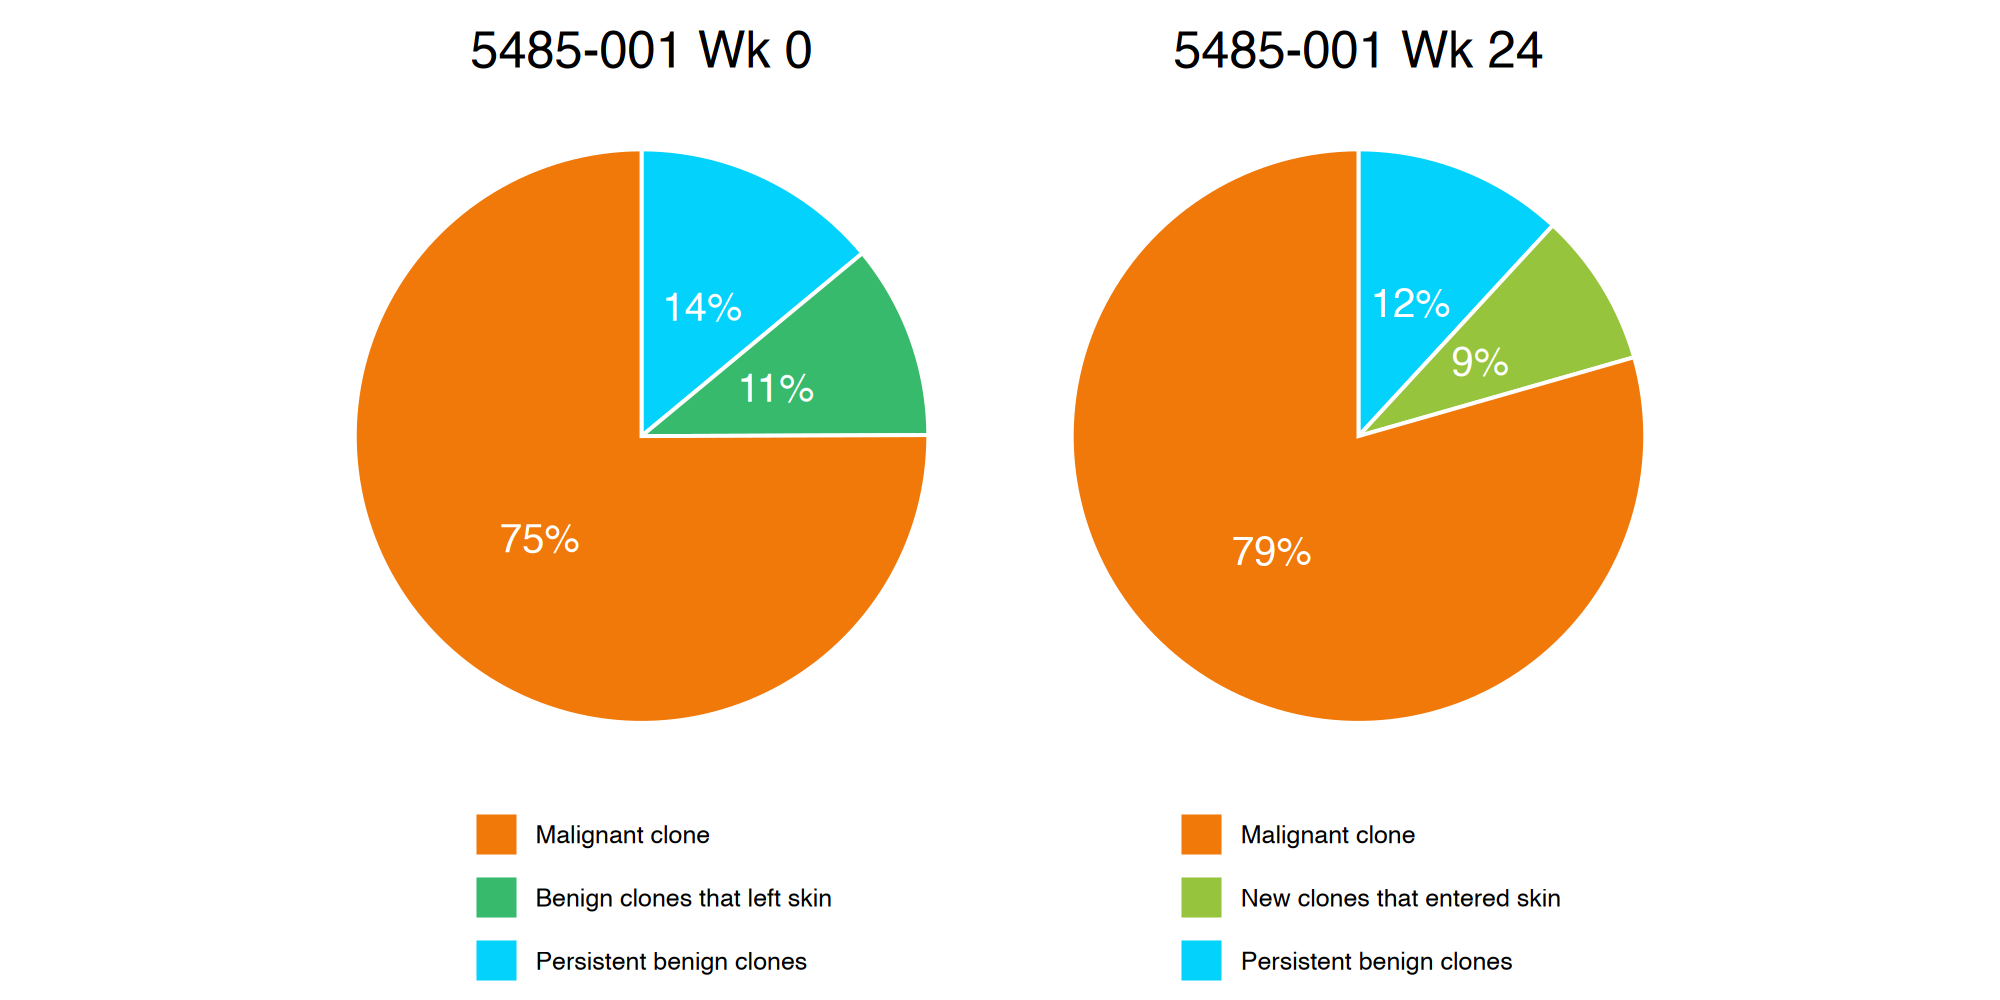

In [2]:
d = read.delim('../_data/HTS/CombinedRearrangements_5485-001.tsv')
sample_name = '5485-001'
colname_LesTxWk24 = 'X5485.001_24Wk_LesTx_TCRBv4b_TCRB'
colname_LesTxWk0 = 'X5485.001_0Wk_LesTx_TCRBv4b_TCRB'

# Define the malignant clone - highest frequency in LesTx Week 0
idx_malignant = which.max(d[, colname_LesTxWk0])

#########################
# LesTx - Week 24
# For Week 24 sample, what percentage are new clones that entered skin
LesTxWk24_percent_new = 0
for (i in c(1:nrow(d))) {
    if (i == idx_malignant) next
    if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] == 0)
        LesTxWk24_percent_new = LesTxWk24_percent_new + d[i, colname_LesTxWk24]
}

# For Week 24 sample, what percentage are existing clones that entered skin
LesTxWk24_percent_existing = 0
for (i in c(1:nrow(d))) {
    if (i == idx_malignant) next
    if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] > 0)
        LesTxWk24_percent_existing = LesTxWk24_percent_existing + d[i, colname_LesTxWk24]
}

# For Week 24 sample, what percentage is malignant
LesTxWk24_percent_malignant = d[idx_malignant, colname_LesTxWk24]

##########################
# LesTx - Week 0
# For Week 0 sample, what percentage are benign clones that left skin
LesTxWk0_percent_left = 0
for (i in c(1:nrow(d))) {
    if (i == idx_malignant) next
    if (d[i, colname_LesTxWk0] > 0 & d[i, colname_LesTxWk24] == 0)
        LesTxWk0_percent_left = LesTxWk0_percent_left + d[i, colname_LesTxWk0]
}

# For Week 0 sample, what percentage are benign clones that persisted in skin
LesTxWk0_percent_persisted = 0
for (i in c(1:nrow(d))) {
    if (i == idx_malignant) next
    if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] > 0)
        LesTxWk0_percent_persisted = LesTxWk0_percent_persisted + d[i, colname_LesTxWk0]
}

# For Week 0 sample, what percentage is malignant
LesTxWk0_percent_malignant = d[idx_malignant, colname_LesTxWk0]

plot_data = data.frame(
    percent = c(
        LesTxWk0_percent_left, LesTxWk0_percent_persisted, LesTxWk0_percent_malignant,
        LesTxWk24_percent_new, LesTxWk24_percent_existing, LesTxWk24_percent_malignant),
    timePt = c(rep('Wk0', 3), rep('Wk24', 3)),
    cloneLabel = c('Benign clones that left skin', 'Persistent benign clones', 'Malignant clone', 
                   'New clones that entered skin', 'Persistent benign clones', 'Malignant clone'))

plot_data$cloneLabel = factor(plot_data$cloneLabel, levels = c('Malignant clone', 'Benign clones that left skin',
                                                              'New clones that entered skin', 'Persistent benign clones'))

color_mapping = c('Benign clones that left skin' = '#38ba6c',
                 'Malignant clone' = '#f0790a',
                 'New clones that entered skin' = '#97c43d',
                 'Persistent benign clones' = '#03d3fc')

################ Make plots #################
plot_Wk0 = plot_data %>% filter(timePt == 'Wk0') %>%
    arrange(desc(cloneLabel)) %>%
    mutate(prop = percent * 100) %>%
    mutate(ypos = cumsum(prop)- 0.5*prop)

plot_Wk24 = plot_data %>% filter(timePt == 'Wk24') %>%
    arrange(desc(cloneLabel)) %>%
    mutate(prop = percent * 100) %>%
    mutate(ypos = cumsum(prop)- 0.5*prop)

# Basic piechart
p0 = ggplot(plot_Wk0, aes(x="", y=prop, fill=cloneLabel)) +
  geom_bar(stat="identity", width=1, color="white") +
  coord_polar("y", start=0) +
  theme_void(base_size = 11) +
  theme(legend.position="none") + theme(plot.title = element_text(size=18)) +
  geom_text(aes(y = ypos, label = paste0(round(prop), '%')), color = "white", size=5) +
  scale_fill_manual(values = color_mapping) + theme(legend.position = 'bottom') +
  ggtitle(paste(sample_name, 'Wk 0')) + labs(fill = '') + theme(plot.title = element_text(hjust = 0.5)) +
    guides(fill=guide_legend(nrow=3,byrow=TRUE))

p24 = ggplot(plot_Wk24, aes(x="", y=prop, fill=cloneLabel)) +
  geom_bar(stat="identity", width=1, color="white") +
  coord_polar("y", start=0) +
  theme_void(base_size = 11) +
  theme(plot.title = element_text(size=18)) +
  geom_text(aes(y = ypos, label = paste0(round(prop), '%')), color = "white", size=5) +
  scale_fill_manual(values = color_mapping) + theme(legend.position = 'bottom') +
  ggtitle(paste(sample_name, 'Wk 24')) + labs(fill = '') + theme(plot.title = element_text(hjust = 0.5)) +
    guides(fill=guide_legend(nrow=3,byrow=TRUE))

fig.size(5, 10)
p0 | p24

In [3]:
head(d)
plot_data

,Rearrangement,Sum..Productive.Frequency.,Present.In,X5485.001_0Wk_LesTx_TCRBv4b_TCRB,X5485.001_0Wk_NL_TCRBv4b_TCRB,X5485.001_0Wk_Untx_TCRBv4b_TCRB,X5485.001_24Wk_LesTx_TCRBv4b_TCRB,X5485.001_24Wk_Untx_TCRBv4b_TCRB
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTGTTGTGGGGAGCTACGAGCAGTACTTCGGGCCG,2.34473899,5,7.505775e-01,0.01572618,0.383223282,7.943696e-01,0.400842421
2,TCCCTGGAGCTTGGTGACTCTGCTGTGTATTTCTGTGCCAGCAGCCAAGAGGCGGGGGGCCTTAATGAAAAACTGTTTTTTGGCAGT,0.03309864,5,1.069473e-04,0.02728955,0.002445586,1.407601e-04,0.003115804
3,CACGCCCTGCAGCCAGAAGACTCAGCCCTGTATCTCTGCGCCAGCAGGGAGAGACAGGGCAGCTCCTACGAGCAGTACTTCGGGCCG,0.02614766,5,3.422313e-04,0.01572618,0.005502568,4.222803e-04,0.004154405
4,ATCCAGCGCACAGAGCAGGAGGACTCGGCCGTGTATCTCTGTGCCAGCAGCTTAGCTAGCGGGACCTACGAGCAGTACTTCGGGCCG,0.02538722,5,8.555784e-05,0.01110083,0.008804109,2.614116e-04,0.005135307
5,GTGAACGCCTTGGAGCTGGACGACTCGGCCCTGTATCTCTGTGCCAGCAGTTCCAGGGGGGTGGGCACTGAAGCTTTCTTTGGACAA,0.02441486,5,6.416838e-05,0.02266420,0.000855955,8.043435e-05,0.000750101
6,ACATCTGTATATTTCTGCGCCAGCAGTGACTGGGACTTCGGGACTAGCGGGACGTTCGCGAACACCGGGGAGCTGTTTTTTGGAGAA,0.01601382,5,3.208419e-04,0.01295097,0.001467351,1.206515e-04,0.001154002


percent,timePt,cloneLabel
<dbl>,<chr>,<fct>
0.10953542,Wk0,Benign clones that left skin
0.13988706,Wk0,Persistent benign clones
0.75057752,Wk0,Malignant clone
0.08707018,Wk24,New clones that entered skin
0.11856023,Wk24,Persistent benign clones
0.79436960,Wk24,Malignant clone


In [4]:
d[1, colname_LesTxWk24]

[1] 0.7943696

In [5]:
colnames(d)

[1] "Rearrangement"                     "Sum..Productive.Frequency."       
[3] "Present.In"                        "X5485.001_0Wk_LesTx_TCRBv4b_TCRB" 
[5] "X5485.001_0Wk_NL_TCRBv4b_TCRB"     "X5485.001_0Wk_Untx_TCRBv4b_TCRB"  
[7] "X5485.001_24Wk_LesTx_TCRBv4b_TCRB" "X5485.001_24Wk_Untx_TCRBv4b_TCRB"

In [6]:
s1 = c('../_data/HTS/CombinedRearrangements_5485-001.tsv', '5485-001', 'P8',
       'X5485.001_0Wk_LesTx_TCRBv4b_TCRB', 'X5485.001_24Wk_LesTx_TCRBv4b_TCRB', '', # No Wk8 LesTx
       'X5485.001_0Wk_Untx_TCRBv4b_TCRB', 'X5485.001_24Wk_Untx_TCRBv4b_TCRB')

s2 = c('../_data/HTS/CombinedRearrangements_5661-002.tsv', '5661-002', 'P1',
       'X5661.002_0Wk_LesTx_TCRBv4b_TCRB', 'X5661.002_24Wk_LesTx_TCRB_TCRB', 'X5661.002_8Wk_LesTx_TCRBv4b_TCRB',
       'X5661.002_0Wk_Untx_TCRBv4b_TCRB', 'X5661.002_24Wk_Untx_TCRB_TCRB')

s3 = c('../_data/HTS/CombinedRearrangements_DF001_8645-001.tsv', '8645-001', 'P13',
       '', 'DF_001_24wk_LesTx_TCRb', 'DF_001_8wk_LesTx_TCRb', # No baseline skin biopsy
       '', 'DF_001_24wk_LesUntx_TCRb') # Does not have Wk0 LesUntx?

s4 = c('../_data/HTS/CombinedRearrangements_DF002_8645-002.tsv', '8645-002', 'P12',
       '', 'DF_002_24wk_LesTx_TCRb', 'DF_002_8wk_LesTx_TCRb',
       '', 'DF_002_24wk_LesUntx_TCRb')
       # same issue as s3

s5 = c('../_data/HTS/CombinedRearrangements_DF010_8645-010.tsv', '8645-010', 'P5',
       'DF_010_0wk_LesTx_TCRb', 'DF_010_Wk24_LesTx082422_TCRB','DF_010_8wk_LesTx_TCRB',
       'DF_010_0wk_LesUntx_TCRb', 'DF_010_Wk24_LesUntx081822_TCRB')
        # Per Jess, use the 08XXXX versions of Wk 24

#s6 = c('../data/HTS/CombinedRearrangements_NW002_8624-002', '8624-002',
#      '', 'NW_002_24Wk_LesTx_TCRB', '',
#      '', 'NW_002_24Wk_LesUntx_TCRB') # This one is missing Wk 0 data and Wk 8

#s7 = c('../data/HTS/CombinedRearrangements_UP001_8428-001', '8428-001') # Does not appear to be CTCL - low frequency

s8 = c('../_data/HTS/CombinedRearrangements_UP003_8428-003.tsv', '8428-003', 'P3',
      'UP_003_0wk_LesTx_TCRBeta', 'UP_003_24wk_LesTx_TCRb', 'UP_003_8wk_LesTx_TCRBeta',
      'UP_003_0wk_LesUntxBxA_TCRBeta', 'UP_003_24wk_LesUntx_TCRb')
        # This one has UP_003_0wk_LesUntxBxA_TCRBeta and UP_003_0wk_LesUntxBxB_TCRBeta - what is "BxA" vs "BxB"

s9 = c('../_data/HTS/CombinedRearrangements_UP005_8428-005.tsv', '8428-005', 'P11',
      'UP_005_0wk_LesTx_TCRBeta', 'UP_005_24wk_LesTx_TCRB', 'UP_005_8wk_LesTx_TCRb',
      'UP_005_0wk_LesUntx_TCRB', 'UP_005_24wk_LesUntx_TCRB')

s10 = c('../_data/HTS/CombinedRearrangements_UP006_8428-006.tsv', '8428-006', 'P7',
       'UP_006_0wk_LesTx_TCRBeta', 'UP_006_24wk_LesTx_TCRB', 'UP_006_8wk_LesTx_TCRb',
       'UP_006_0wk_LesUntx_TCRBeta', 'UP_006_24wk_LesUntx_TCRB')

s11 = c('../_data/HTS/CombinedRearrangements_UP008_8428-008.tsv', '8428-008', 'P9',
       'UP_008_0wk_LesTx_TCRb', 'UP_008_24Wk_LesTx_TCRB', 'UP_008_8wk_LesTx_TCRb',
       'UP_008_0wk_LesUntx_TCRb', 'UP_008_24Wk_LesUntx_TCRB')

s12 = c('../_data/HTS/CombinedRearrangements_UP010_8428-010.tsv', '8428-010', 'P2',
       'UP_010_0wk_LesTx_TCRB', 'UP_010_24wk_LesTx_TCRB', 'UP_010_8Wk_LesTx_TCRB',
       'UP_010_0wk_LesUntx_TCRB', 'UP_010_24wk_LesUntx_TCRB')

s13 = c('../_data/HTS/CombinedRearrangements_UP011_8428-011.tsv', '8428-011', 'P10',
       'UP_011_0wk_LesTx_TCRB', 'UP_011_24_wk_LexTx_TCRB', 'UP_011_8Wk_LesTx_TCRB',
       'UP_011_0wk_LesUntx_TCRB', 'UP_011_24_wk_LesUnTx_TCRB')

s14 = c('../_data/HTS/CombinedRearrangements_UP013_8428-013.tsv', '8428-013', 'P4',
       'UP_013_0Wk_LesTx_TCRB', 'UP_013_24_wk_LesTx_TCRb', '', # No Wk8 LesTx - TODO
       'UP_013_0Wk_LesUntx_TCRB', 'UP_013_24_wk_LesUntx_TCRb')

tdat = rbind(s1, s2, s3, s4, s5, s8, s9, s10, s11, s12, s13, s14)
colnames(tdat) = c('filepath', 'Subject', 'PatientID', 
            'LesTx_Wk0col', 'LesTx_Wk24col', 'LesTx_Wk8col', 'LesUntx_Wk0col', 'LesUntx_Wk24col')
head(tdat)

,filepath,Subject,PatientID,LesTx_Wk0col,LesTx_Wk24col,LesTx_Wk8col,LesUntx_Wk0col,LesUntx_Wk24col
s1,../_data/HTS/CombinedRearrangements_5485-001.tsv,5485-001,P8,X5485.001_0Wk_LesTx_TCRBv4b_TCRB,X5485.001_24Wk_LesTx_TCRBv4b_TCRB,,X5485.001_0Wk_Untx_TCRBv4b_TCRB,X5485.001_24Wk_Untx_TCRBv4b_TCRB
s2,../_data/HTS/CombinedRearrangements_5661-002.tsv,5661-002,P1,X5661.002_0Wk_LesTx_TCRBv4b_TCRB,X5661.002_24Wk_LesTx_TCRB_TCRB,X5661.002_8Wk_LesTx_TCRBv4b_TCRB,X5661.002_0Wk_Untx_TCRBv4b_TCRB,X5661.002_24Wk_Untx_TCRB_TCRB
s3,../_data/HTS/CombinedRearrangements_DF001_8645-001.tsv,8645-001,P13,,DF_001_24wk_LesTx_TCRb,DF_001_8wk_LesTx_TCRb,,DF_001_24wk_LesUntx_TCRb
s4,../_data/HTS/CombinedRearrangements_DF002_8645-002.tsv,8645-002,P12,,DF_002_24wk_LesTx_TCRb,DF_002_8wk_LesTx_TCRb,,DF_002_24wk_LesUntx_TCRb
s5,../_data/HTS/CombinedRearrangements_DF010_8645-010.tsv,8645-010,P5,DF_010_0wk_LesTx_TCRb,DF_010_Wk24_LesTx082422_TCRB,DF_010_8wk_LesTx_TCRB,DF_010_0wk_LesUntx_TCRb,DF_010_Wk24_LesUntx081822_TCRB
s8,../_data/HTS/CombinedRearrangements_UP003_8428-003.tsv,8428-003,P3,UP_003_0wk_LesTx_TCRBeta,UP_003_24wk_LesTx_TCRb,UP_003_8wk_LesTx_TCRBeta,UP_003_0wk_LesUntxBxA_TCRBeta,UP_003_24wk_LesUntx_TCRb


## Analysis for all samples - Wk 0 vs. Wk 24 - Treated lesions

Ignore the NL samples

Focus on Week 0 and 24 for LesTx (ignore week 8)


In [7]:
color_mapping = c('Benign clones that left skin' = '#38ba6c',
                 'Malignant clone' = '#f0790a',
                 'New clones that entered skin' = '#97c43d',
                 'Persistent benign clones' = '#03d3fc')

pie_chart = function(data, week = 'Wk 24') {
    p = ggplot(data, aes(x="", y=prop, fill=cloneLabel)) +
        geom_bar(stat="identity", width=1, color="white") +
        coord_polar("y", start=0) + theme_void(base_size = 11) + theme(legend.position="none") + theme(plot.title = element_text(size=18)) +
        geom_text(aes(y = ypos, label = paste0(round(prop), '%')), color = "white", size=5) +
        scale_fill_manual(values = color_mapping) + theme(legend.position = 'bottom') + ggtitle(paste(sample_name, week)) + 
        labs(fill = '') + theme(plot.title = element_text(hjust = 0.5)) + guides(fill=guide_legend(nrow = 3, byrow=TRUE)) +
        theme(legend.text=element_text(size=11))
}

In [8]:
results = NULL
for (i in c(1:nrow(tdat))) {
    
    filepath = tdat[i, 'filepath']
    d = read.delim(filepath)
    
    sample_name = tdat[i, 'PatientID']
    colname_LesTxWk0 = tdat[i, 'LesTx_Wk0col']
    colname_LesTxWk8 = tdat[i, 'LesTx_Wk8col']
    colname_LesTxWk24 = tdat[i, 'LesTx_Wk24col']
    
    message(sample_name)
    
    if(colname_LesTxWk0 == '') {
        message('Skipping- missing LesTxWk0')
        next
    }
    
    # Define the malignant clone - highest frequency in LesTx Week 0
    idx_malignant = which.max(d[, colname_LesTxWk0])
    # if patient is 8428-006, define malignant clone as highest frequency in LesUntx Week 0
    if (sample_name == 'P7') {
        idx_malignant = which.max(d[, tdat[i, 'LesUntx_Wk0col']])
    }
    
    #########################
    # LesTx - Week 24
    LesTxWk24_percent_entered = 0 # What percentage are new clones that entered skin?
    LesTxWk24_num_entered = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] == 0) {
            LesTxWk24_percent_entered = LesTxWk24_percent_entered + d[i, colname_LesTxWk24]
            LesTxWk24_num_entered = LesTxWk24_num_entered + 1}
        }

    LesTxWk24_percent_persisted = 0 # What percentage are existing clones that persisted in skin?
    LesTxWk24_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] > 0) {
            LesTxWk24_percent_persisted = LesTxWk24_percent_persisted + d[i, colname_LesTxWk24]
            LesTxWk24_num_persisted = LesTxWk24_num_persisted + 1}
        }
    
    ##########################
    # LesTx - Week 0
    LesTxWk0_percent_left = 0 # What percentage are benign clones that left skin?
    LesTxWk0_num_left = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk0] > 0 & d[i, colname_LesTxWk24] == 0) {
            LesTxWk0_percent_left = LesTxWk0_percent_left + d[i, colname_LesTxWk0]
            LesTxWk0_num_left = LesTxWk0_num_left + 1}
        }

    LesTxWk0_percent_persisted = 0 # What percentage are benign clones that persisted in skin?
    LesTxWk0_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk24] > 0 & d[i, colname_LesTxWk0] > 0) {
            LesTxWk0_percent_persisted = LesTxWk0_percent_persisted + d[i, colname_LesTxWk0]
            LesTxWk0_num_persisted = LesTxWk0_num_persisted + 1}
    }
    
    # For Week 24 sample, what percentage is malignant
    LesTxWk24_percent_malignant = d[idx_malignant, colname_LesTxWk24]
    # For Week 0 sample, what percentage is malignant
    LesTxWk0_percent_malignant = d[idx_malignant, colname_LesTxWk0]
    
    plot_data = data.frame(
        percent = c(LesTxWk0_percent_left, LesTxWk0_percent_persisted, LesTxWk0_percent_malignant,
                    LesTxWk24_percent_entered, LesTxWk24_percent_persisted, LesTxWk24_percent_malignant),
        num = c(LesTxWk0_num_left, LesTxWk0_num_persisted, 1, LesTxWk24_num_entered, LesTxWk24_num_persisted, 1),
        timePt = c(rep('Wk0', 3), rep('Wk24', 3)),
        cloneLabel = c('Benign clones that left skin', 'Persistent benign clones', 'Malignant clone',
                       'New clones that entered skin', 'Persistent benign clones', 'Malignant clone'))

    plot_data$cloneLabel = factor(plot_data$cloneLabel, 
                levels = c('Malignant clone', 'Benign clones that left skin', 'New clones that entered skin', 'Persistent benign clones'))

    # Percent change in malignant clone
    percent_change_malig = (LesTxWk24_percent_malignant - LesTxWk0_percent_malignant) / LesTxWk0_percent_malignant
    percent_change_malig2 = (LesTxWk24_percent_malignant - LesTxWk0_percent_malignant)
    
    result = c(sample_name, LesTxWk24_num_entered, LesTxWk24_percent_entered, 
               LesTxWk24_num_persisted, LesTxWk24_percent_persisted, 
               percent_change_malig, percent_change_malig2)
    results = rbind(results, result)
    
    ################ Make plots #################
    plot_Wk0 = plot_data %>% filter(timePt == 'Wk0') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    plot_Wk24 = plot_data %>% filter(timePt == 'Wk24') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    # Basic piechart
    p0 = pie_chart(plot_Wk0, week = 'Wk 0')
    p24 = pie_chart(plot_Wk24, week = 'Wk 24')

    fig.size(4, 8)
    pdf(paste0('../_results/HTS/clonal_tracking/', sample_name, '_Wk0_24_plot.pdf'), width = 8, height = 4)
    print(p0 | p24)
    dev.off()
}
colnames(results) = c('Subject', 'num_clones_entered', 'percent_clones_entered', 'num_clones_persisted', 'percent_clones_persisted', 
                     'percent_change_malignant', 'percent_change_malignant2')
write.csv(results, paste0('../_results/HTS/clonal_tracking/results_Tx_Wk0_Wk24.csv'), quote = FALSE)

P8

P1

P13

Skipping- missing LesTxWk0

P12

Skipping- missing LesTxWk0

P5

P3

P11

P7

P9

P2

P10

P4



In [9]:
results = as.data.frame(results)
results = results %>% mutate(num_clones_entered = as.numeric(num_clones_entered),
                   percent_clones_entered = as.numeric(percent_clones_entered),
                   num_clones_persisted = as.numeric(num_clones_persisted),
                   percent_clones_persisted = as.numeric(percent_clones_persisted),
                   percent_change_malignant = as.numeric(percent_change_malignant))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


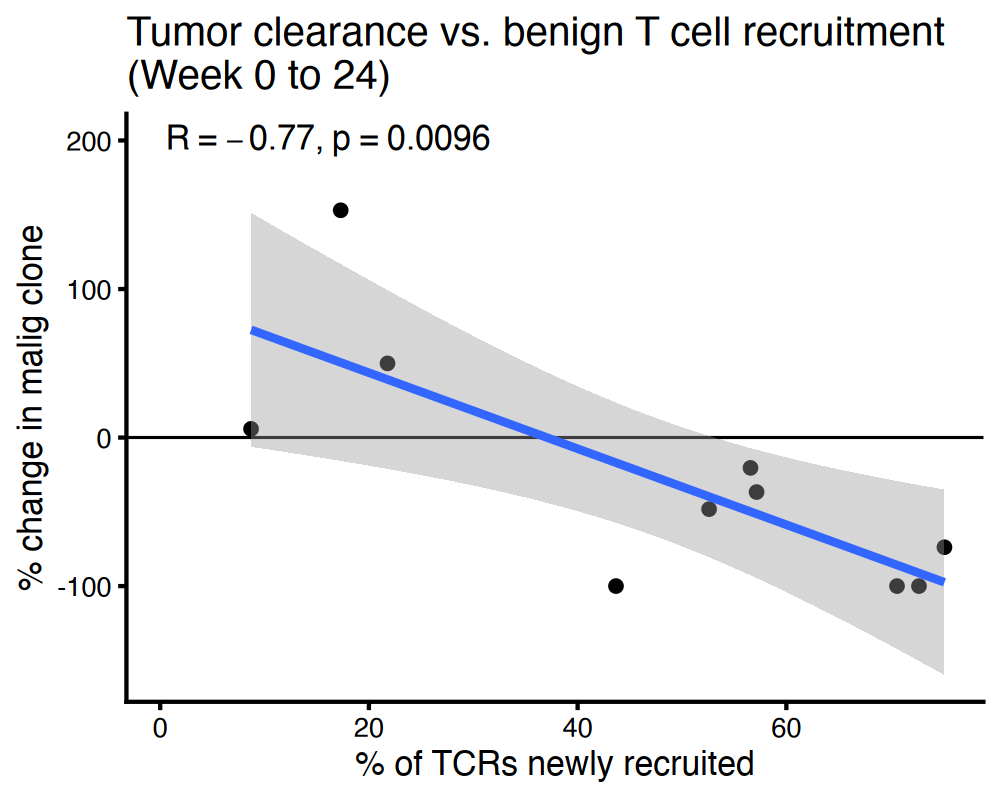

In [10]:
fig.size(4, 5)
results %>% 
    ggplot(aes(x = percent_clones_entered*100, y = percent_change_malignant*100)) +
        geom_hline(yintercept=0, color = "black", size = 0.4) +
        geom_point() +
        theme_classic(base_size = 12) + stat_cor(method = "pearson", label.x = 0.5, label.y = 200) +
        geom_smooth(method='lm', formula= y~x) + 
        xlab("% of TCRs newly recruited") + ylab('% change in malig clone') +
        ggtitle('Tumor clearance vs. benign T cell recruitment\n(Week 0 to 24)')

# Analysis for all samples - Wk 0 vs. Wk 24 - Untreated lesions

Ignore the NL samples

Focus on Week 0 and 24 LesUntx


In [11]:
results = NULL
for (i in c(1:nrow(tdat))) {
    
    filepath = tdat[i, 'filepath']
    d = read.delim(filepath)
    
    sample_name = tdat[i, 'PatientID']
    colname_LesTxWk0 = tdat[i, 'LesTx_Wk0col']
    colname_LesUntxWk0 = tdat[i, 'LesUntx_Wk0col']
    colname_LesUntxWk24 = tdat[i, 'LesUntx_Wk24col']
    
    message(sample_name)
    if (colname_LesTxWk0 == '' | colname_LesTxWk24 == '') {
        message(paste('Missing Tx sample, skipping', sample_name))
        next
    }
    
    if (colname_LesUntxWk0 == '' | colname_LesUntxWk24 == '') {
        message(paste('Missing Untx sample, skipping', sample_name))
        next
    }
    
    # Define the malignant clone - highest frequency in LesTx Week 0
    idx_malignant_Tx = which.max(d[, colname_LesTxWk0])
    idx_malignant_Untx = which.max(d[, colname_LesUntxWk0])
    if (idx_malignant_Tx == idx_malignant_Untx){
        message(paste('Same malignant clone in Tx and Untx:', d[idx_malignant_Tx, 'Rearrangement']))
    } else {
        message('Different malignant clone in Tx and Untx')
    }
    idx_malignant = idx_malignant_Untx
    
    #########################
    # LesUntx - Week 24
    LesUntxWk24_percent_entered = 0 # What percentage are new clones that entered skin?
    LesUntxWk24_num_entered = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesUntxWk24] > 0 & d[i, colname_LesUntxWk0] == 0) {
            LesUntxWk24_percent_entered = LesUntxWk24_percent_entered + d[i, colname_LesUntxWk24]
            LesUntxWk24_num_entered = LesUntxWk24_num_entered + 1}
        }

    LesUntxWk24_percent_persisted = 0 # What percentage are existing clones that persisted in skin?
    LesUntxWk24_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesUntxWk24] > 0 & d[i, colname_LesUntxWk0] > 0) {
            LesUntxWk24_percent_persisted = LesUntxWk24_percent_persisted + d[i, colname_LesUntxWk24]
            LesUntxWk24_num_persisted = LesUntxWk24_num_persisted + 1}
        }
    
    ##########################
    # LesUntx - Week 0
    LesUntxWk0_percent_left = 0 # What percentage are benign clones that left skin?
    LesUntxWk0_num_left = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesUntxWk0] > 0 & d[i, colname_LesUntxWk24] == 0) {
            LesUntxWk0_percent_left = LesUntxWk0_percent_left + d[i, colname_LesUntxWk0]
            LesUntxWk0_num_left = LesUntxWk0_num_left + 1}
        }

    LesUntxWk0_percent_persisted = 0 # What percentage are benign clones that persisted in skin?
    LesUntxWk0_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesUntxWk24] > 0 & d[i, colname_LesUntxWk0] > 0) {
            LesUntxWk0_percent_persisted = LesUntxWk0_percent_persisted + d[i, colname_LesUntxWk0]
            LesUntxWk0_num_persisted = LesUntxWk0_num_persisted + 1}
        }
    
    # For Week 24 sample, what percentage is malignant
    LesUntxWk24_percent_malignant = d[idx_malignant, colname_LesUntxWk24]
    # For Week 0 sample, what percentage is malignant
    LesUntxWk0_percent_malignant = d[idx_malignant, colname_LesUntxWk0]
    
    plot_data = data.frame(
        percent = c(LesUntxWk0_percent_left, LesUntxWk0_percent_persisted, LesUntxWk0_percent_malignant,
                    LesUntxWk24_percent_entered, LesUntxWk24_percent_persisted, LesUntxWk24_percent_malignant),
        num = c(LesUntxWk0_num_left, LesUntxWk0_num_persisted, 1, LesUntxWk24_num_entered, LesUntxWk24_num_persisted, 1),
        timePt = c(rep('Wk0', 3), rep('Wk24', 3)),
        cloneLabel = c('Benign clones that left skin', 'Persistent benign clones', 'Malignant clone',
                       'New clones that entered skin', 'Persistent benign clones', 'Malignant clone'))

    plot_data$cloneLabel = factor(plot_data$cloneLabel, 
                levels = c('Malignant clone', 'Benign clones that left skin', 'New clones that entered skin', 'Persistent benign clones'))

    # Percent change in malignant clone
    LesUntxWk0_percent_malignant = d[idx_malignant, colname_LesUntxWk0]
    LesUntxWk24_percent_malignant = d[idx_malignant, colname_LesUntxWk24]
    percent_change_malig = (LesUntxWk24_percent_malignant - LesUntxWk0_percent_malignant) / LesUntxWk0_percent_malignant
    percent_change_malig2 = (LesUntxWk24_percent_malignant - LesUntxWk0_percent_malignant)
    
    result = c(sample_name, LesUntxWk24_num_entered, LesUntxWk24_percent_entered, 
               LesUntxWk24_num_persisted, LesUntxWk24_percent_persisted, 
               percent_change_malig, percent_change_malig2)
    results = rbind(results, result)
    
    ################ Make plots #################
    plot_Wk0 = plot_data %>% filter(timePt == 'Wk0') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    plot_Wk24 = plot_data %>% filter(timePt == 'Wk24') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    # Basic piechart
    p0 = pie_chart(plot_Wk0, week = 'Wk 0')

    p24 = pie_chart(plot_Wk24, week = 'Wk 24')

    fig.size(4, 8)
    pdf(paste0('../_results/HTS/clonal_tracking/', sample_name, '_Untx_Wk0_24_plot.pdf'), width = 8, height = 4)
    print(p0 | p24)
    dev.off()
}
colnames(results) = c('Subject', 'num_clones_entered', 'percent_clones_entered', 
                     'num_clones_persisted', 'percent_clones_persisted', 'percent_change_malignant', 
                      'percent_change_malignant2')
write.csv(results, paste0('../_results/HTS/clonal_tracking/results_Untx_Wk0_Wk24.csv'), quote = FALSE)

P8

Same malignant clone in Tx and Untx: ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTGTTGTGGGGAGCTACGAGCAGTACTTCGGGCCG

P1

Same malignant clone in Tx and Untx: GGGGACTCGGCCCTTTATCTTTGCGCCAGCAGCTTGGATCGGGACTCCAGGGTCGGGCGAACCAAAAACATTCAGTACTTCGGCGCC

P13

Missing Tx sample, skipping P13

P12

Missing Tx sample, skipping P12

P5

Same malignant clone in Tx and Untx: ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTTTATCCCGGGGGCAGCCCCAGCATTTTGGTGAT

P3

Same malignant clone in Tx and Untx: GGGTTGGAGTCGGCTGCTCCCTCCCAAACATCTGTGTACTTCTGTGCCAGCATTAATAGGGGCAATCAGCCCCAGCATTTTGGTGAT

P11

Same malignant clone in Tx and Untx: GAGTCTGCCATCCCCAACCAGACAGCTCTTTACTTCTGTGCCACCAGCGTGGGGGGGGCCCCCTACAATGAGCAGTTCTTCGGGCCA

P7

Different malignant clone in Tx and Untx

P9

Same malignant clone in Tx and Untx: TCGGCTGCTCCCTCCCAAACATCTGTGTACTTCTGTGCCAGCAGTACCCCGGTGGGGGGGAATGGCCAGCCCCAGCATTTTGGTGAT

P2

Same malignant clone in Tx and Untx: CACATCAATTCCCTGGAGCTTGGTGACTCTGCTGTGTATTTCTGTGCCAGCAGCCC

# Analysis for all samples - Wk 0 vs. Wk 8 - Treated lesions

Ignore the NL samples

Focus on Week 0 and 8 for LesTx


In [12]:
results = NULL
for (i in c(1:nrow(tdat))) {
    
    filepath = tdat[i, 'filepath']
    d = read.delim(filepath)
    
    sample_name = tdat[i, 'PatientID']
    colname_LesTxWk0 = tdat[i, 'LesTx_Wk0col']
    colname_LesTxWk8 = tdat[i, 'LesTx_Wk8col']
    
    message(sample_name)
    if (colname_LesTxWk0 == '' | colname_LesTxWk8 == '') {
        message(paste('Missing Tx sample, skipping', sample_name))
        next
    }
    # Define the malignant clone - highest frequency in LesTx Week 0
    idx_malignant = which.max(d[, colname_LesTxWk0])
    
    # if patient is 8428-006, define malignant clone as highest frequency in LesUntx Week 0
    if (sample_name == 'P7') {
        idx_malignant = which.max(d[, tdat[i, 'LesUntx_Wk0col']])
    }
    
    #########################
    # LesTx - Week 8
    LesTxWk8_percent_entered = 0 # What percentage are new clones that entered skin?
    LesTxWk8_num_entered = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk8] > 0 & d[i, colname_LesTxWk0] == 0) {
            LesTxWk8_percent_entered = LesTxWk8_percent_entered + d[i, colname_LesTxWk8]
            LesTxWk8_num_entered = LesTxWk8_num_entered + 1}
        }

    LesTxWk8_percent_persisted = 0 # What percentage are existing clones that persisted in skin?
    LesTxWk8_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk8] > 0 & d[i, colname_LesTxWk0] > 0) {
            LesTxWk8_percent_persisted = LesTxWk8_percent_persisted + d[i, colname_LesTxWk8]
            LesTxWk8_num_persisted = LesTxWk8_num_persisted + 1}
        }
    
    ##########################
    # LesTx - Week 0
    LesTxWk0_percent_left = 0 # What percentage are benign clones that left skin?
    LesTxWk0_num_left = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk0] > 0 & d[i, colname_LesTxWk8] == 0){
            LesTxWk0_percent_left = LesTxWk0_percent_left + d[i, colname_LesTxWk0]
            LesTxWk0_num_left = LesTxWk0_num_left + 1}
        }

    LesTxWk0_percent_persisted = 0 # What percentage are benign clones that persisted in skin?
    LesTxWk0_num_persisted = 0
    for (i in c(1:nrow(d))) {
        if (i == idx_malignant) next
        if (d[i, colname_LesTxWk8] > 0 & d[i, colname_LesTxWk0] > 0){
            LesTxWk0_percent_persisted = LesTxWk0_percent_persisted + d[i, colname_LesTxWk0]
            LesTxWk0_num_persisted = LesTxWk0_num_persisted + 1}
        }
    
    # For Week 8 sample, what percentage is malignant
    LesTxWk8_percent_malignant = d[idx_malignant, colname_LesTxWk8]
    # For Week 0 sample, what percentage is malignant
    LesTxWk0_percent_malignant = d[idx_malignant, colname_LesTxWk0]
    
    plot_data = data.frame(
        percent = c(LesTxWk0_percent_left, LesTxWk0_percent_persisted, LesTxWk0_percent_malignant,
                    LesTxWk8_percent_entered, LesTxWk8_percent_persisted, LesTxWk8_percent_malignant),
        num = c(LesTxWk0_num_left, LesTxWk0_num_persisted, 1, LesTxWk8_num_entered, LesTxWk8_num_persisted, 1),
        timePt = c(rep('Wk0', 3), rep('Wk8', 3)),
        cloneLabel = c('Benign clones that left skin', 'Persistent benign clones', 'Malignant clone',
                       'New clones that entered skin', 'Persistent benign clones', 'Malignant clone'))

    plot_data$cloneLabel = factor(plot_data$cloneLabel, 
                levels = c('Malignant clone', 'Benign clones that left skin', 'New clones that entered skin', 'Persistent benign clones'))

    # Percent change in malignant clone
    LesTxWk0_percent_malignant = d[idx_malignant, colname_LesTxWk0]
    LesTxWk8_percent_malignant = d[idx_malignant, colname_LesTxWk8]
    percent_change_malig = (LesTxWk8_percent_malignant - LesTxWk0_percent_malignant) / LesTxWk0_percent_malignant
    percent_change_malig2 = (LesTxWk8_percent_malignant - LesTxWk0_percent_malignant)
    
    result = c(sample_name, LesTxWk8_num_entered, LesTxWk8_percent_entered, LesTxWk8_num_persisted, 
               LesTxWk8_percent_persisted, percent_change_malig, percent_change_malig2)
    results = rbind(results, result)
    
    ################ Make plots #################
    plot_Wk0 = plot_data %>% filter(timePt == 'Wk0') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    plot_Wk8 = plot_data %>% filter(timePt == 'Wk8') %>%
        arrange(desc(cloneLabel)) %>%
        mutate(prop = percent / sum(percent) * 100) %>%
        mutate(ypos = cumsum(prop)- 0.5*prop)

    # Basic piechart
    p0 = pie_chart(plot_Wk0, week = 'Wk 0')

    p8 = pie_chart(plot_Wk8, week = 'Wk 8')

    fig.size(4, 8)
    pdf(paste0('../_results/HTS/clonal_tracking/', sample_name, '_Wk0_8_plot.pdf'), width = 8, height = 4)
    print(p0 | p8)
    dev.off()
}
colnames(results) = c('Subject', 'num_clones_entered', 'percent_clones_entered', 
                     'num_clones_persisted', 'percent_clones_persisted', 'percent_change_malignant',
                      'percent_change_malignant2')
write.csv(results, paste0('../_results/HTS/clonal_tracking/results_Tx_Wk0_Wk8.csv'), quote = FALSE)

P8

Missing Tx sample, skipping P8

P1

P13

Missing Tx sample, skipping P13

P12

Missing Tx sample, skipping P12

P5

P3

P11

P7

P9

P2

P10

P4

Missing Tx sample, skipping P4



In [13]:
results = as.data.frame(results)
results = results %>% mutate(num_clones_entered = as.numeric(num_clones_entered),
                   percent_clones_entered = as.numeric(percent_clones_entered),
                   num_clones_persisted = as.numeric(num_clones_persisted),
                   percent_clones_persisted = as.numeric(percent_clones_persisted),
                   percent_change_malignant = as.numeric(percent_change_malignant))

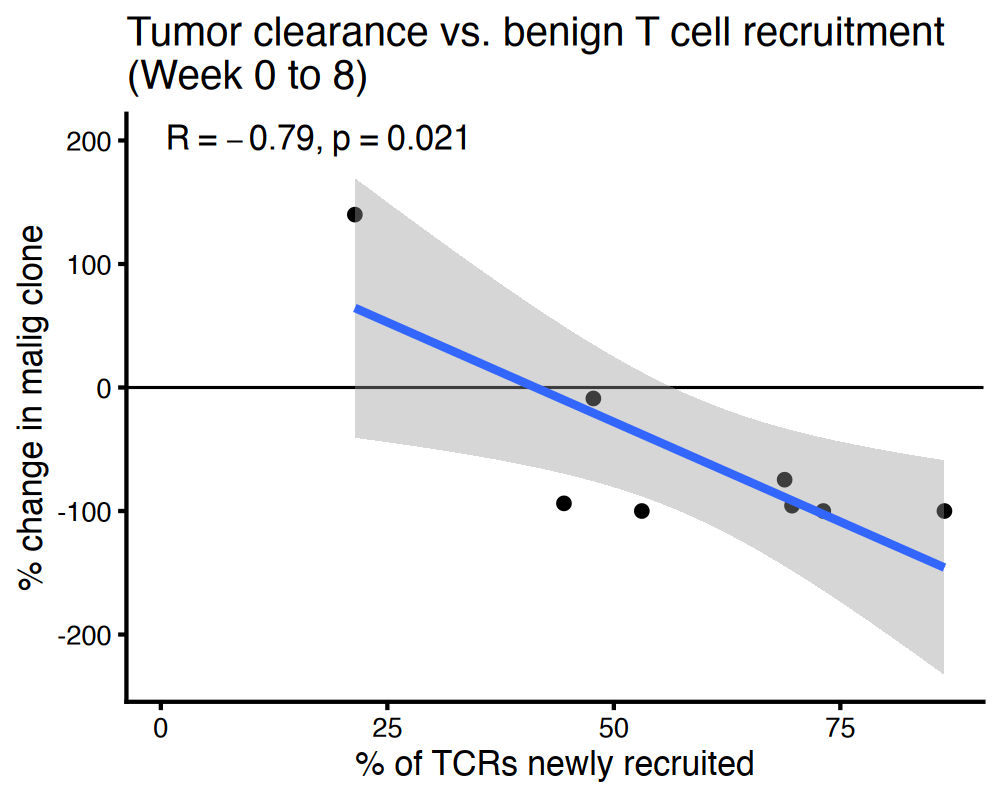

In [14]:
fig.size(4, 5)
results %>% 
    ggplot(aes(x = percent_clones_entered*100, y = percent_change_malignant*100)) +
        geom_hline(yintercept=0, color = "black", size = 0.4) +
        geom_point() +
        theme_classic(base_size = 12) + stat_cor(method = "pearson", label.x = 0.5, label.y = 200) +
        geom_smooth(method='lm', formula= y~x) + 
        xlab("% of TCRs newly recruited") + ylab('% change in malig clone') +
        ggtitle('Tumor clearance vs. benign T cell recruitment\n(Week 0 to 8)')

# Plot all

In [15]:
results1 = read.csv('../_results/HTS/clonal_tracking/results_Tx_Wk0_Wk24.csv')
results1$Tx = 'Treated Lesional (Wk 0 to 24)'
results2 = read.csv('../_results/HTS/clonal_tracking/results_Untx_Wk0_Wk24.csv')
results2$Tx = 'Untreated Lesional (Wk 0 to 24)'
results3 = read.csv('../_results/HTS/clonal_tracking/results_Tx_Wk0_Wk8.csv')
results3$Tx = 'Treated Lesional (Wk 0 to 8)'
results_combined = rbind(results1, results2, results3)

In [16]:
results_combined$Tx = factor(results_combined$Tx, levels = c('Treated Lesional (Wk 0 to 8)',
                                                            'Treated Lesional (Wk 0 to 24)',
                                                            'Untreated Lesional (Wk 0 to 24)'))

agg_record_18484284bf7db 
                       2

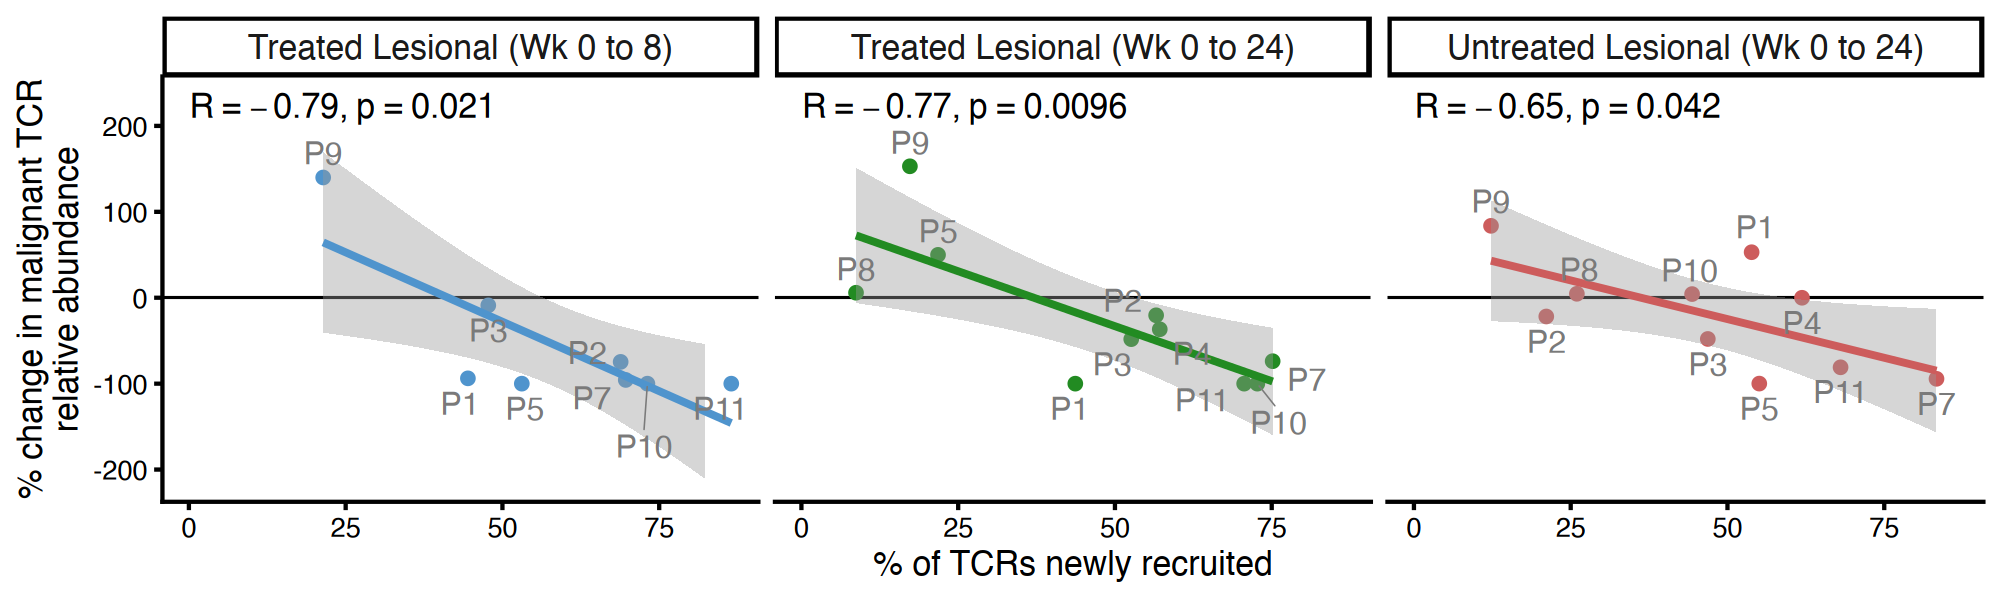

In [17]:
fig.size(3, 10)
p = results_combined %>% 
    ggplot(aes(x = percent_clones_entered*100, y = percent_change_malignant*100)) +
        geom_hline(yintercept=0, color = "black", size = 0.4) +
        geom_point(aes(col = Tx)) +
        theme_classic(base_size = 12) + stat_cor(method = "pearson", label.x = 0.1, label.y = 220) +
        geom_smooth(method='lm', formula= y~x, lwd = 1, aes(col = Tx)) + 
        xlab("% of TCRs newly recruited") + ylab('% change in malignant TCR\nrelative abundance') +
        geom_text_repel(aes(x = percent_clones_entered*100, y = percent_change_malignant*100,
                            label = Subject), size = 4, segment.size = 0.2, col = 'gray48',
                            nudge_y = 8 * sign(results_combined$percent_change_malignant), force = 12) + 
        facet_wrap(~Tx, ncol = 3) + ylim(-215, 235) +
        theme(legend.position = 'none') + scale_color_manual(values = c('steelblue3', 'forestgreen', 'indianred')) +
        theme(strip.text.x = element_text(size = 12))

pdf('../_figures/malignant_clone_change_vs_recruitment.pdf', width = 10, height = 3)
print(p)
dev.off()
p

In [18]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sonoma 14.6

Matrix products: default
BLAS/LAPACK: /opt/anaconda3/envs/resiq/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] org.Hs.eg.db_3.20.0         AnnotationDbi_1.68.0       
 [3] msigdbr_26.1.0              clusterProfiler_4.14.0     
 [5] rlang_1.2.0                 scales_1.4.0               
 [7] patchwork_1.3.2             RColorBrewer_1.1-3         
 [9] rstatix_0.7.3               mixtools_2.0.0.1           
[11] limma_3.62.2                cowplot_1.2.0              
[13] ggrastr_1.0.2               ggpubr_0.6.3               
[15] lme4_2.0-1                  singlecellmethods_0.1.0    
[17] MAST_1.32.0           